# Module 4 - Policy Strategy, Dashboard and Executive Communication
Nigeria Macroeconomic Intelligence & Labour Market Analytics Platform

Deliverables: KPI Dashboard | Macro Overview Chart | Policy Memo | Key Findings Summary

## Setup - Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
warnings.filterwarnings('ignore')

DATA   = os.getcwd()
OUTPUT = os.path.join(DATA, 'outputs')
os.makedirs(OUTPUT, exist_ok=True)
print(f"Working directory: {DATA}")
print(f"Output folder    : {OUTPUT}")

Working directory: /home/a0878fb7-b331-4998-8538-65574a32993a
Output folder    : /home/a0878fb7-b331-4998-8538-65574a32993a/outputs


In [2]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.dpi': 120,
})
print("Style configured.")

Style configured.


## Load Datasets

In [3]:
gdp    = pd.read_csv('nigeria_quarterly_gdp.csv')
cpi    = pd.read_csv('nigeria_cpi_monthly.csv')
lfs    = pd.read_csv('nigeria_labour_force_quarterly.csv')
states = pd.read_csv('nigeria_state_unemployment_2023.csv')
wb     = pd.read_csv('worldbank_nigeria_annual_full.csv')
oil_m  = pd.read_csv('nigeria_oil_production_monthly.csv')
exp    = pd.read_csv('nigeria_gdp_expenditure_annual.csv')
panel  = pd.read_csv('nigeria_master_quarterly_panel.csv')
print("All datasets loaded.")

All datasets loaded.


## Extract Latest KPI Values

In [4]:
latest_gdp   = gdp['gdp_growth_yoy_pct'].iloc[-1]
prev_gdp     = gdp['gdp_growth_yoy_pct'].iloc[-2]
latest_inf   = cpi['headline_inflation_pct'].iloc[-1]
prev_inf     = cpi['headline_inflation_pct'].iloc[-2]
latest_unem  = lfs['unemployment_rate_pct'].iloc[-1]
prev_unem    = lfs['unemployment_rate_pct'].iloc[-2]
latest_inf_r = lfs['informal_employment_rate_pct'].iloc[-1]
latest_oil   = oil_m['oil_revenue_ngn_bn'].iloc[-1]
prev_oil     = oil_m['oil_revenue_ngn_bn'].iloc[-2]

print(f"GDP Growth (Q4 2023)         : {latest_gdp:.1f}%  (prev: {prev_gdp:.1f}%)")
print(f"Headline Inflation (Dec 2023): {latest_inf:.1f}%  (prev: {prev_inf:.1f}%)")
print(f"Unemployment (Q4 2023)       : {latest_unem:.1f}%  (prev: {prev_unem:.1f}%)")
print(f"Informal Employment (Q4 2023): {latest_inf_r:.1f}%")
print(f"Oil Revenue (Dec 2023)       : NGN {latest_oil:.0f}bn")

GDP Growth (Q4 2023)         : 3.5%  (prev: 3.5%)
Headline Inflation (Dec 2023): 28.9%  (prev: 28.2%)
Unemployment (Q4 2023)       : 30.7%  (prev: 31.0%)
Informal Employment (Q4 2023): 91.1%
Oil Revenue (Dec 2023)       : NGN 838bn


## Task 4.1 - KPI Dashboard

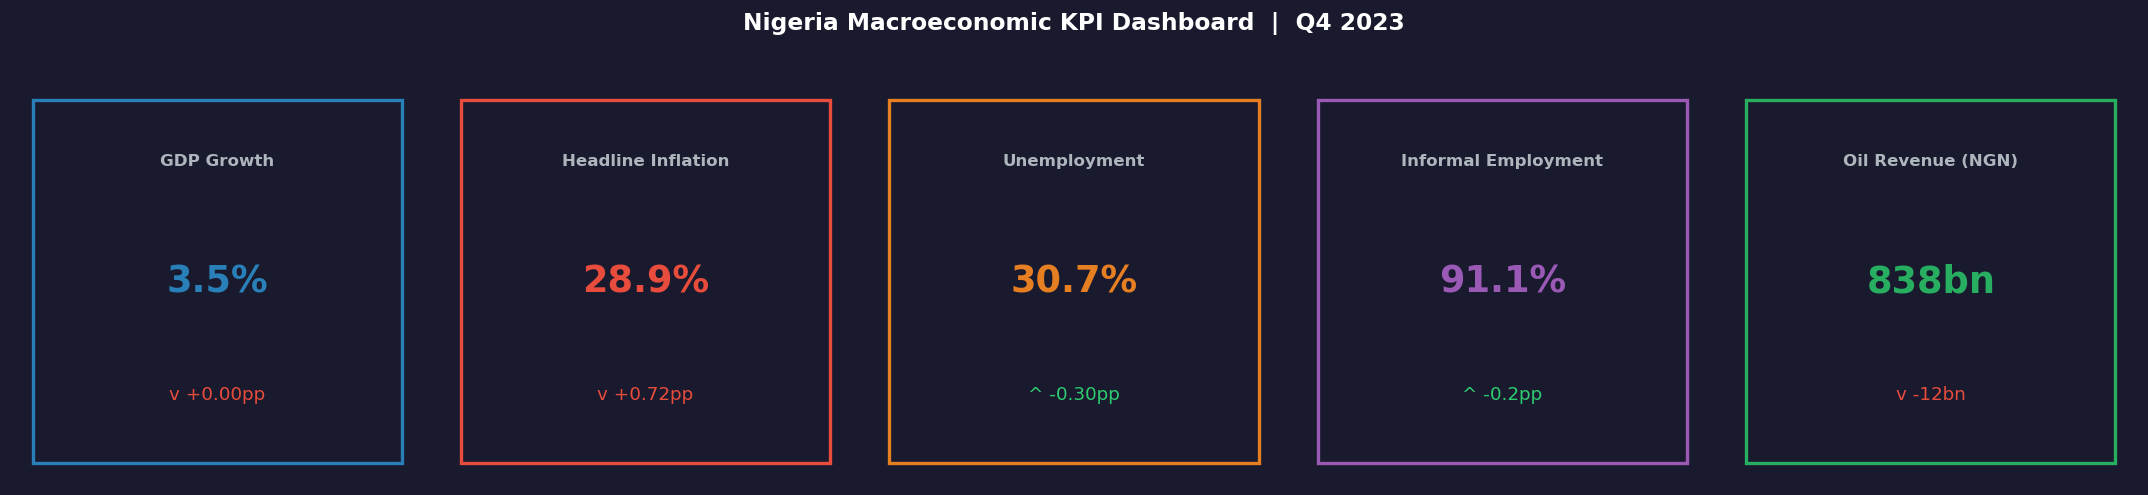

In [5]:
kpis = [
    ('GDP Growth',         f'{latest_gdp:.1f}%',   f'{latest_gdp-prev_gdp:+.2f}pp', latest_gdp>prev_gdp,   '#2980b9'),
    ('Headline Inflation', f'{latest_inf:.1f}%',   f'{latest_inf-prev_inf:+.2f}pp', latest_inf<prev_inf,   '#e74c3c'),
    ('Unemployment',       f'{latest_unem:.1f}%',  f'{latest_unem-prev_unem:+.2f}pp',latest_unem<prev_unem,'#e67e22'),
    ('Informal Employment',f'{latest_inf_r:.1f}%', '-0.2pp',                         True,                  '#9b59b6'),
    ('Oil Revenue (NGN)',  f'{latest_oil:.0f}bn',  f'{latest_oil-prev_oil:+.0f}bn',  latest_oil>prev_oil,  '#27ae60'),
]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.patch.set_facecolor('#1a1a2e')
for ax, (label, value, delta, positive, color) in zip(axes, kpis):
    ax.set_facecolor('#16213e')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    ax.text(0.5, 0.80, label,  ha='center', va='center', fontsize=10,  color='#adb5bd', fontweight='bold',  transform=ax.transAxes)
    ax.text(0.5, 0.50, value,  ha='center', va='center', fontsize=22,  color=color,     fontweight='bold',  transform=ax.transAxes)
    arrow       = '^' if positive else 'v'
    delta_color = '#2ecc71' if positive else '#e74c3c'
    ax.text(0.5, 0.22, f'{arrow} {delta}', ha='center', va='center', fontsize=11, color=delta_color, transform=ax.transAxes)
    ax.add_patch(plt.Rectangle((0.05,0.05), 0.90, 0.90, linewidth=2, edgecolor=color, facecolor='none', transform=ax.transAxes))
fig.suptitle('Nigeria Macroeconomic KPI Dashboard  |  Q4 2023', fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'mod4_kpi_dashboard.png'), dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## Composite Macro Overview Chart

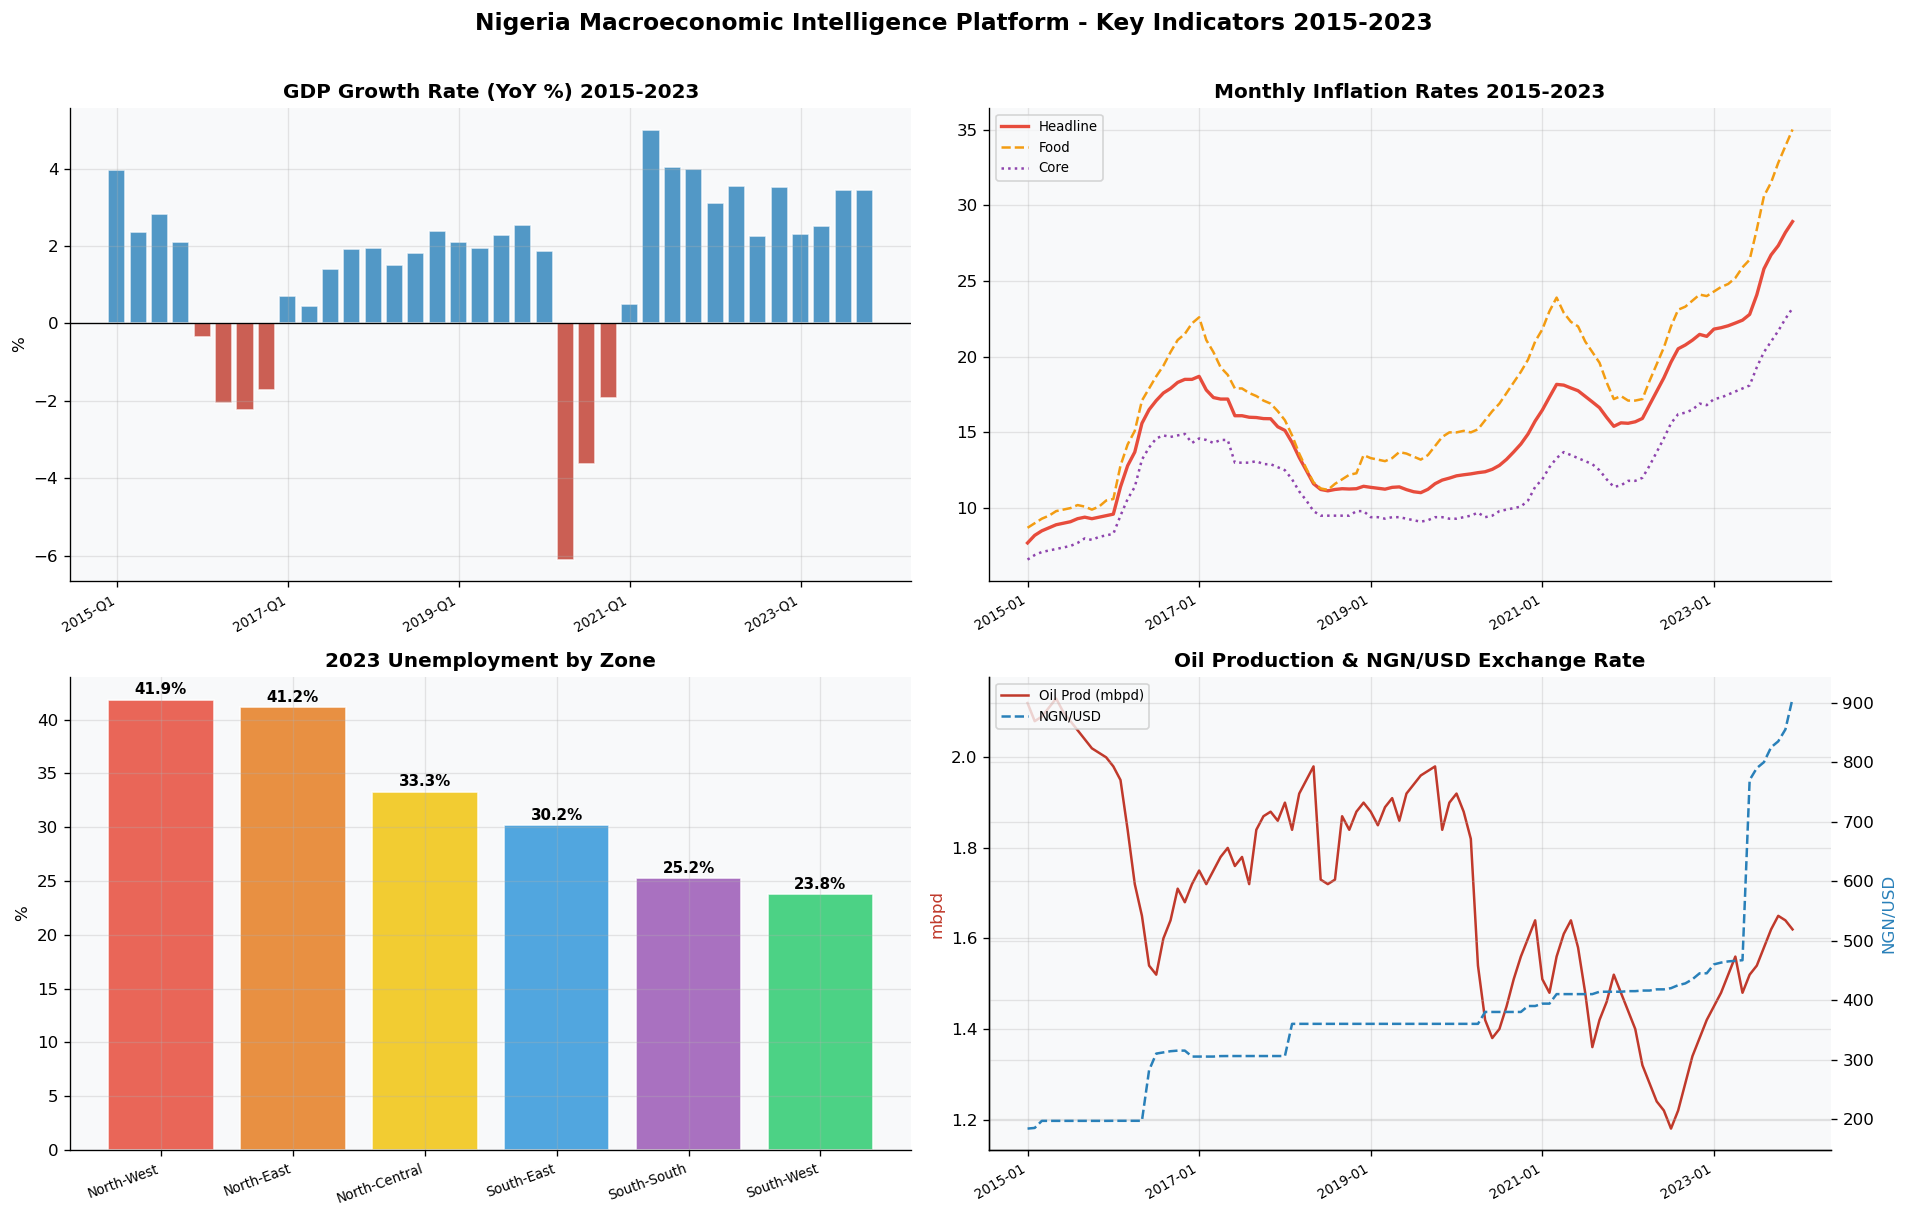

In [6]:
zone_palette = {
    'North-West':'#e74c3c','North-East':'#e67e22','North-Central':'#f1c40f',
    'South-West':'#2ecc71','South-East':'#3498db','South-South':'#9b59b6'
}
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0,0]
cols = ['#c0392b' if v<0 else '#2980b9' for v in gdp['gdp_growth_yoy_pct']]
ax.bar(range(len(gdp)), gdp['gdp_growth_yoy_pct'], color=cols, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('GDP Growth Rate (YoY %) 2015-2023', fontweight='bold')
ax.set_ylabel('%')
ax.set_xticks(range(0,len(gdp),8))
ax.set_xticklabels(gdp['period'].iloc[::8], rotation=30, ha='right', fontsize=8)

ax = axes[0,1]
ax.plot(range(len(cpi)), cpi['headline_inflation_pct'], color='#e74c3c', linewidth=2,   label='Headline')
ax.plot(range(len(cpi)), cpi['food_inflation_pct'],     color='#f39c12', linewidth=1.5, label='Food',    linestyle='--')
ax.plot(range(len(cpi)), cpi['core_inflation_pct'],     color='#8e44ad', linewidth=1.5, label='Core',    linestyle=':')
ax.set_title('Monthly Inflation Rates 2015-2023', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xticks(range(0,len(cpi),24))
ax.set_xticklabels(cpi['period'].iloc[::24], rotation=30, ha='right', fontsize=8)

ax = axes[1,0]
zone_avg = states.groupby('geopolitical_zone')['unemployment_rate_2023'].mean().sort_values(ascending=False)
bars = ax.bar(range(len(zone_avg)), zone_avg.values, color=[zone_palette[z] for z in zone_avg.index], alpha=0.85, edgecolor='white')
for b, v in zip(bars, zone_avg.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(zone_avg)))
ax.set_xticklabels(zone_avg.index, rotation=20, ha='right', fontsize=8)
ax.set_title('2023 Unemployment by Zone', fontweight='bold')
ax.set_ylabel('%')

ax  = axes[1,1]
ax2 = ax.twinx()
ax.plot(range(len(oil_m)),  oil_m['oil_production_mbpd'],  color='#c0392b', linewidth=1.5, label='Oil Prod (mbpd)')
ax2.plot(range(len(oil_m)), oil_m['exchange_rate_ngn_usd'], color='#2980b9', linewidth=1.5, linestyle='--', label='NGN/USD')
ax.set_title('Oil Production & NGN/USD Exchange Rate', fontweight='bold')
ax.set_ylabel('mbpd', color='#c0392b')
ax2.set_ylabel('NGN/USD', color='#2980b9')
ax.set_xticks(range(0,len(oil_m),24))
ax.set_xticklabels(oil_m['period'].iloc[::24], rotation=30, ha='right', fontsize=8)
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, fontsize=8, loc='upper left')

plt.suptitle('Nigeria Macroeconomic Intelligence Platform - Key Indicators 2015-2023', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'mod4_macro_overview.png'), dpi=120, bbox_inches='tight')
plt.show()

## Task 4.2 - Policy Memo

In [7]:
policy_memo = """
================================================================================
INTERNAL MEMORANDUM
TO:     Chief Investment Officer & Head of Nigeria Operations
FROM:   Analytics Team
DATE:   Q4 2023
RE:     Nigeria Macroeconomic Intelligence - Investment Risk & Opportunity Brief
================================================================================

SITUATION SUMMARY

As of end-2023, Nigeria's economy presents a bifurcated picture: real GDP growth
held at 3.5% in Q4 2023, sustained by a resilient non-oil private sector - yet
headline inflation breached 28.9%, driven by the June 2023 petrol subsidy removal
and naira float that depreciated the exchange rate from NGN 467 to over NGN 907
per USD within six months. This combination of moderate growth and accelerating
inflation represents the single most critical risk to local-currency-denominated
portfolio returns in the near term.

PRIORITY RECOMMENDATIONS

1. HEDGE NAIRA EXPOSURE ON ALL LOCAL-CURRENCY POSITIONS [HIGH PRIORITY]
   Exchange rate is the statistically dominant driver of headline inflation
   (OLS coef=0.026 per NGN/USD, p<0.001, Adj R^2=0.63). Prophet model 12-month
   forecast projects continued inflationary pressure at 29-34% through mid-2024.
   Recommendation: restructure at least 60% of NGN-denominated instruments into
   USD-linked instruments within 90 days.

2. OVERWEIGHT NON-OIL SECTORS - TELECOM, FINTECH, AGRIBUSINESS [HIGH PRIORITY]
   Non-oil GDP growth (mean 1.83% quarterly) outpaces oil sector (-0.59%) across
   2015-2023. Post-COVID recovery averaged 3.14% vs 1.29% pre-COVID (t-test
   p=0.005, Cohen d=1.04). Recommendation: allocate new capital into fintech
   infrastructure, digital agriculture, and logistics. Target: Q1-Q2 2024.

3. PRIORITISE SOUTHERN STATES FOR DEPLOYMENT [MEDIUM PRIORITY]
   ANOVA confirms significant unemployment inequality across zones (F=10.65,
   p<0.001, eta^2=0.63). North-West and North-East average 18pp higher
   unemployment than South-West and South-South. Recommendation: weight project
   financing toward Lagos, Rivers, and South-West; apply 300-400bp risk premium
   for Northern-state exposures.

INFLATION OUTLOOK

Prophet 12-month forecast: inflation above 25% through H1 2024, moderating to
22-24% by Q4 2024. Real return hurdle rate: 30%+ NGN yield required to generate
positive USD-equivalent returns.

Baseline GDP forecast 2024-2025: 4.0%. Downside (oil $55, NGN -20%): ~1.8%.
Upside (oil $100): ~6.2%. Scenario gap: ~$16B USD.

All figures: NBS, World Bank, CBN 2015-2023.
================================================================================
"""
print(policy_memo)


INTERNAL MEMORANDUM
TO:     Chief Investment Officer & Head of Nigeria Operations
FROM:   Analytics Team
DATE:   Q4 2023
RE:     Nigeria Macroeconomic Intelligence - Investment Risk & Opportunity Brief

SITUATION SUMMARY

As of end-2023, Nigeria's economy presents a bifurcated picture: real GDP growth
held at 3.5% in Q4 2023, sustained by a resilient non-oil private sector - yet
headline inflation breached 28.9%, driven by the June 2023 petrol subsidy removal
and naira float that depreciated the exchange rate from NGN 467 to over NGN 907
per USD within six months. This combination of moderate growth and accelerating
inflation represents the single most critical risk to local-currency-denominated
portfolio returns in the near term.

PRIORITY RECOMMENDATIONS

1. HEDGE NAIRA EXPOSURE ON ALL LOCAL-CURRENCY POSITIONS [HIGH PRIORITY]
   Exchange rate is the statistically dominant driver of headline inflation
   (OLS coef=0.026 per NGN/USD, p<0.001, Adj R^2=0.63). Prophet model 12-month
   f

In [8]:
with open(os.path.join(OUTPUT, 'policy_memo.txt'), 'w') as f:
    f.write(policy_memo)
print(f"Policy memo saved to: {os.path.join(OUTPUT, 'policy_memo.txt')}")

Policy memo saved to: /home/a0878fb7-b331-4998-8538-65574a32993a/outputs/policy_memo.txt


## Task 4.3 - Key Findings Summary

In [9]:
findings = pd.DataFrame([
    {'Module':'M1 EDA',   'Finding':'Nigeria GDP contracted -6.1% in Q2 2020 (COVID trough); recovered to +5.0% in Q2 2021',   'Figure':'Q2 2020: -6.1% | Q2 2021: +5.0%',     'Source':'NBS Quarterly GDP'},
    {'Module':'M1 EDA',   'Finding':'Headline inflation surged from 22.8% to 28.9% in 6 months post June 2023 subsidy removal', 'Figure':'+6.1pp in 6 months',                   'Source':'NBS Monthly CPI'},
    {'Module':'M1 EDA',   'Finding':'Zamfara highest unemployment (47.4%); FCT Abuja lowest (12.8%)',                           'Figure':'Gap: 34.6pp',                           'Source':'NBS LFS 2023'},
    {'Module':'M1 EDA',   'Finding':'Oil price has moderate positive correlation with GDP growth',                               'Figure':'Pearson r = 0.668',                     'Source':'World Bank & NBS'},
    {'Module':'M2 Stats', 'Finding':'Significant regional unemployment inequality across geopolitical zones',                    'Figure':'F=10.65, p<0.001, eta^2=0.63',          'Source':'One-Way ANOVA'},
    {'Module':'M2 Stats', 'Finding':'Post-COVID growth (3.14%) significantly exceeds pre-COVID (1.29%)',                        'Figure':'t=-3.46, p=0.005, d=-1.04',             'Source':'Paired t-Test'},
    {'Module':'M2 Stats', 'Finding':'Exchange rate is dominant independent driver of headline inflation',                       'Figure':'coef=0.026, p<0.001, Adj R^2=0.63',     'Source':'Multiple OLS'},
    {'Module':'M2 Stats', 'Finding':'Northern zones show perfect association with high informality (>90%)',                     'Figure':'chi^2=48.0, p<0.001, Cramer V=1.0',    'Source':'Chi-Square Test'},
    {'Module':'M3 Model', 'Finding':'ARIMA(1,1,1) outperforms SARIMAX on test RMSE for GDP growth forecasting',                'Figure':'ARIMA RMSE=1.12 vs SARIMAX RMSE=3.20', 'Source':'Model Comparison'},
    {'Module':'M3 Model', 'Finding':'Prophet forecasts inflation above 25% through H1 2024',                                    'Figure':'MAPE=12.2%',                            'Source':'Meta Prophet'},
    {'Module':'M3 Model', 'Finding':'Urban population share is top SHAP predictor of state unemployment',                      'Figure':'CV RMSE=2.69, Train R^2=1.0',           'Source':'XGBoost + SHAP'},
    {'Module':'M3 Model', 'Finding':'Upside-downside GDP scenario gap for 2024-2025 is ~$16B USD',                             'Figure':'Upside 6.2% vs Downside 1.8%',          'Source':'Scenario Analysis'},
])
findings.to_csv(os.path.join(OUTPUT, 'key_findings_summary.csv'), index=False)
print(f"Key findings saved: {len(findings)} findings")
findings

Key findings saved: 12 findings


,Module,Finding,Figure,Source
0,M1 EDA,Nigeria GDP contracted -6.1% in Q2 2020 (COVID...,Q2 2020: -6.1% | Q2 2021: +5.0%,NBS Quarterly GDP
1,M1 EDA,Headline inflation surged from 22.8% to 28.9% ...,+6.1pp in 6 months,NBS Monthly CPI
2,M1 EDA,Zamfara highest unemployment (47.4%); FCT Abuj...,Gap: 34.6pp,NBS LFS 2023
3,M1 EDA,Oil price has moderate positive correlation wi...,Pearson r = 0.668,World Bank & NBS
4,M2 Stats,Significant regional unemployment inequality a...,"F=10.65, p<0.001, eta^2=0.63",One-Way ANOVA
5,M2 Stats,Post-COVID growth (3.14%) significantly exceed...,"t=-3.46, p=0.005, d=-1.04",Paired t-Test
6,M2 Stats,Exchange rate is dominant independent driver o...,"coef=0.026, p<0.001, Adj R^2=0.63",Multiple OLS
7,M2 Stats,Northern zones show perfect association with h...,"chi^2=48.0, p<0.001, Cramer V=1.0",Chi-Square Test
8,M3 Model,"ARIMA(1,1,1) outperforms SARIMAX on test RMSE ...",ARIMA RMSE=1.12 vs SARIMAX RMSE=3.20,Model Comparison
9,M3 Model,Prophet forecasts inflation above 25% through ...,MAPE=12.2%,Meta Prophet


## Module 4 Complete

All deliverables saved to the outputs folder:
- mod4_kpi_dashboard.png
- mod4_macro_overview.png
- policy_memo.txt
- key_findings_summary.csv